<p align="center">
  <img src="fig/wrfhydro_logo.png" alt="WRF-Hydro Logo" width="15%">
  &nbsp;&nbsp;&nbsp; <!-- adds horizontal space -->
  <img src="fig/Coupling_preparation.png" alt="Coupling Preparation" width="70%">
</p>

# WRF-Hydro/MODFLOW Domain Setup: Step 2 — MODFLOW Subsetting and Reprojecting to WRF-Hydro Grid

This Python notebook defines and creates the case-specific model domain and initial conditions for MODFLOW.

## Authors

**First Version:** Built upon Wesley Zell (wzell@usgs.gov) CONUS MODFLOW subsetting tool (ngwm1.0_viz_and_subset.ipynb)  

**Created by:** Farshid Felfelani  
Research Applications Laboratory, NSF National Center for Atmospheric Research  

- **Email:** felfelan@ucar.edu

- This notebook: 
    - Interacts with the CONUS-extent datasets and modeldata that has been re-packaged to netCDF from the ScienceBase data release.

Requirements for this notebook included in the **ngwm1.0_viz conda environment**.
  
Data assumed to be structured as:  
ngwm1.0  
|- data  # Files used to specify the domain, boundary condition indexing, and system properties  
|- stageddata  # Files reprojected/resampled and georeferenced to the ngwm1.0 CONUS-extent domain  
|- framedata  # MODFLOW framework data (tops and bottoms)    
|- pakdata  # MODFLOW package data (stages and conductances)  
|- modeldata  # MODFLOW simulated states and output translated from the heads and budget binaries

---


In [1]:
import os
import flopy
import shutil
import rasterio
import rioxarray

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

from pyproj import CRS
from shapely.geometry import Point
from cartopy import crs as ccrs
from rasterio.transform import from_origin
from os.path import exists

import matplotlib.pyplot as plt
import hvplot.pandas  # noqa
import hvplot.xarray  # noqa

In [2]:
import subprocess, sys

In [3]:
subprocess.run('pwd', shell=True)

/glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial


CompletedProcess(args='pwd', returncode=0)

## 1. Setting ENV variables of the Notebook

In [4]:
# replacing WRF-Hydro Top?
# need to make sure whether to update GHB and CHD stages with new surface data?
replaceTop = False

dxdy = 250
version = "01"

# case = "rep", "drb"
case = "drb"

tag = case + "_" + str(dxdy) + "m" + "_v" + version

ngwm_root = os.path.join('../MODFLOW', 'ngwm')
wrfh_root = os.path.join('./wrfhydro_cutout', tag)

output_root = os.path.join("./modflow_cutout", tag)

if not os.path.exists(output_root):
    os.makedirs(output_root)

ngwm_tag = 'ngwm1.0'
ngwm_dxdy = 250

modelname = 'modflow_subset'

class _Paths():

    def __init__(self, project_root, output_root, tag, dxdy):
        """This class maps several attributes to files of
        interest in the directory structure and simplifies file access."""

        grid_id = '{}_{}'.format(ngwm_tag, dxdy)
        stageddata_dir = os.path.join(ngwm_root, ngwm_tag, 'stageddata')

        framedata_dir = os.path.join(ngwm_root, ngwm_tag, 'framedata')
        pakdata_dir = os.path.join(ngwm_root, ngwm_tag, 'pakdata')
        modeldata_dir = os.path.join(ngwm_root, ngwm_tag, 'modeldata')

        domain_nc = self._nc(dirname=stageddata_dir, varnme='domain', grid_id=grid_id)

        # For convenience - make all the local variables (i.e., within the scope of this instance) class attributes.
        self.__dict__.update({k: v for k, v in locals().items() if k != 'self'})

        return

    def _nc(self, dirname, varnme, grid_id=None):

        if grid_id is None:
            grid_id = self.grid_id

        return os.path.join(dirname, '{}_{}.nc'.format(grid_id, varnme))


Paths = _Paths(project_root=ngwm_root, output_root=output_root, 
               tag=ngwm_tag, dxdy=ngwm_dxdy)

## 2. Prints and Plots

In [5]:
Paths.tag

'ngwm1.0'

In [ ]:
Paths.domain_nc

In [ ]:
Paths.modeldata_dir

In [8]:
domain_dat = xr.open_dataset(Paths.domain_nc, format="NetCDF4")
print(domain_dat["domain0"].values.min(), domain_dat["domain0"].values.max())

nan nan


In [9]:
print(np.ma.masked_invalid(domain_dat["domain0"].values).min(), np.ma.masked_invalid(domain_dat["domain0"].values).max())

1.0 1.0


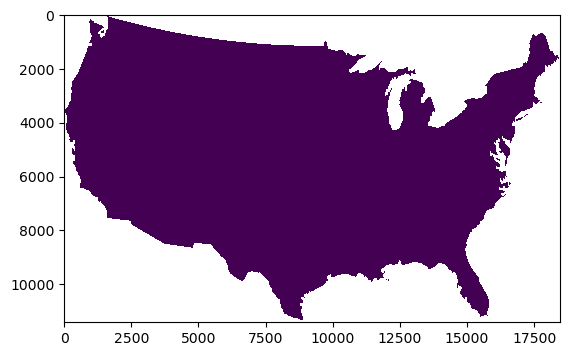

In [10]:
plt.imshow(domain_dat["domain0"].values)

In [11]:
Paths.output_root

'/glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01'

## 3. MODFLOW Subsetting

**rioxarray approach: resample ngwm1.0 data to different resolution/projection**

Generate a MODFLOW6 simulation for a subset grid.

In [12]:
# The workspace for the subsetting example
sim_ws = os.path.join(Paths.output_root, modelname)

if not os.path.isdir(sim_ws):
    os.makedirs(sim_ws)

os.chdir(sim_ws)

In [13]:
print(np.__version__)

1.26.2


In [14]:
# Erase all directory contents except for the MODFLOW binary
for ifile in [os.path.join(sim_ws, f) for f in os.listdir(sim_ws) if not f == 'mf6.exe']:
    if os.path.isfile(ifile):
        print("Removing ... ", ifile)
        os.remove(ifile)

Removing ...  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.chd_stage
Removing ...  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.ghb_conductance
Removing ...  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.idomain
Removing ...  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.drn_conductance
Removing ...  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.startingheads
Removing ...  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.top
Removing ...  

### Initial setup

In [15]:
!module load nco

Copying the geo grid and meta data files to make a standard nc file with all the projection info as an attribute for HGT_M variable

In [16]:
file_in = os.path.join(wrfh_root, "GEOGRID_LDASOUT_Spatial_Metadata.nc")
file_out = os.path.join(Paths.output_root, "GEOGRID_LDASOUT_Spatial_Metadata_bak.nc")

if not os.path.isfile(file_out):
    shutil.copyfile(file_in, file_out)

file_in = os.path.join(wrfh_root, "geo_em.d01.nc")
file_out = os.path.join(Paths.output_root, "geo_em.d01_bak.nc")

if not os.path.isfile(file_out):
    shutil.copyfile(file_in, file_out)

### Ranaming dimensions to match those in MODFLOW files

In [17]:
subprocess.run("ncrename -d west_east,x " + os.path.join(Paths.output_root, "geo_em.d01_bak.nc"), shell=True)

ncrename: ERROR Required dimension 'west_east' is not present in input file. HINT: If presence is intended to be optional, then prefix old dimension name with the period character '.', i.e., 'ncrename -d .west_east,x'. With this syntax ncrename would succeed even when no such dimension is in the file.


CompletedProcess(args='ncrename -d west_east,x /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/geo_em.d01_bak.nc', returncode=1)

In [18]:
subprocess.run("ncrename -d south_north,y " + os.path.join(Paths.output_root, "geo_em.d01_bak.nc"), shell=True)

ncrename: ERROR Required dimension 'south_north' is not present in input file. HINT: If presence is intended to be optional, then prefix old dimension name with the period character '.', i.e., 'ncrename -d .south_north,y'. With this syntax ncrename would succeed even when no such dimension is in the file.


CompletedProcess(args='ncrename -d south_north,y /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/geo_em.d01_bak.nc', returncode=1)

### Adding Geogrid Variables to the Spatial Metadata File

In some cases, you may wish to **add a variable from the geogrid file** (e.g., `HGT_M`, representing terrain height) to the **spatial metadata file**, typically named  
`GEOGRID_LDASOUT_Spatial_Metadata`.  

This metadata file serves as the **main spatial reference file** for WRF-Hydro preprocessing outputs—it contains all relevant **projection information** and includes a dedicated **`crs`** variable that defines the coordinate reference system.  

By including a geogrid variable such as `HGT_M` in this file, you ensure that important spatial information (e.g., topography) is carried along with the coordinate metadata. This can be useful for quality control, visualization, or initializing subsequent WRF-Hydro or MODFLOW preprocessingsteps.


In [19]:
subprocess.run("ncks -A -v HGT_M " + os.path.join(Paths.output_root, "geo_em.d01_bak.nc ") + os.path.join(Paths.output_root, "GEOGRID_LDASOUT_Spatial_Metadata_bak.nc"), shell=True)

CompletedProcess(args='ncks -A -v HGT_M /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/geo_em.d01_bak.nc /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/GEOGRID_LDASOUT_Spatial_Metadata_bak.nc', returncode=0)

### Adding a Grid Mapping Attribute to the Geogrid Variable

When adding a variable such as **`HGT_M`** (terrain height) to the spatial metadata file, it is important to include a **grid mapping attribute** that links the variable to the coordinate reference system (CRS) information.  

Specifically, you should add a **`grid_mapping` attribute** to the `HGT_M` variable, pointing to the existing **`crs`** variable within the `GEOGRID_LDASOUT_Spatial_Metadata` file.  
This ensures that geospatially aware libraries such as **xarray**, **rioxarray**, or **cf-xarray** can correctly interpret the projection and coordinate information associated with each variable.

The `grid_mapping` attribute acts as a pointer that associates `HGT_M` (and any other spatial variable) with the `crs` variable containing all relevant projection metadata (e.g., projection type, central meridian, standard parallels, datum,

**Why This Is Needed?**

When you open a NetCDF file in **xarray**, the `grid_mapping` attribute enables automatic decoding of coordinate reference information.  
If the attribute is missing, xarray cannot infer the projection metadata for the variable, and spatial operations (such as reprojection or plotting with georeferenced axes) may fail or be inaccurat
decode_coords=“all”: Set variables referred to in 'grid_mapping', 'bounds' and other attributes as coordinate variables.
e.

To ensure proper interpretation, you should open datasets using:

```python
xr.open_dataset("GEOGRID_LDASOUT_Spatial_Metadata.nc", decode_coords="all") etc.).


In [20]:
subprocess.run("ncatted -O -a grid_mapping,HGT_M,o,c,'crs' " + 
               os.path.join(Paths.output_root, "GEOGRID_LDASOUT_Spatial_Metadata_bak.nc ") + 
                            os.path.join(Paths.output_root, "GEOGRID_LDASOUT_Spatial_Metadata_bakfin.nc "), shell=True)

CompletedProcess(args="ncatted -O -a grid_mapping,HGT_M,o,c,'crs' /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/GEOGRID_LDASOUT_Spatial_Metadata_bak.nc /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/GEOGRID_LDASOUT_Spatial_Metadata_bakfin.nc ", returncode=0)

In [21]:
src_griddom_nc = Paths._nc(Paths.framedata_dir, varnme='frame_top')
src_griddom  = xr.open_dataset(src_griddom_nc, decode_coords='all')['top']

dst_griddom_nc = os.path.join(os.path.join(Paths.output_root, "GEOGRID_LDASOUT_Spatial_Metadata_bakfin.nc"))
dst_griddom = xr.open_dataset(dst_griddom_nc, decode_coords='all')['HGT_M']

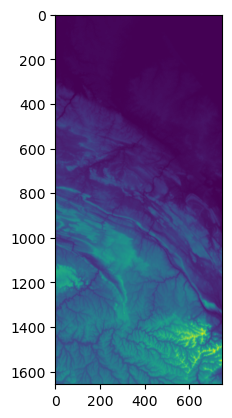

In [23]:
plt.imshow(dst_griddom.data[0], origin = "upper")

### Do we need to flip?

In [24]:
dst_griddom_flip = dst_griddom.copy(deep=True)
dst_griddom_flip = dst_griddom_flip.reindex(y=list(reversed(dst_griddom_flip.y))) # Flipping the data
dst_griddom_flip.y.data[:10]

array([-206998.14344547, -206748.14344547, -206498.14344547,
       -206248.14344547, -205998.14344547, -205748.14344547,
       -205498.14344547, -205248.14344547, -204998.14344547,
       -204748.14344547])

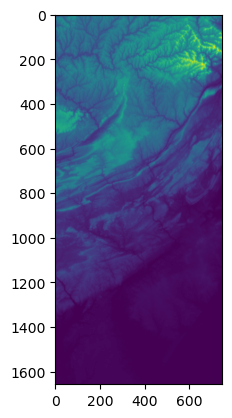

In [25]:
plt.imshow(dst_griddom_flip.data[0], origin = "upper")

## 4. MODFLOW Reproject

In [27]:
def print_raster(raster):
    print(
        f"shape: {raster.rio.shape}\n"
        f"resolution: {raster.rio.resolution()}\n"
        f"bounds: {raster.rio.bounds()}\n"
        f"sum: {raster.sum().item()}\n"
        f"CRS: {raster.rio.crs}\n"
    )

In [28]:
print("Original Raster:\n----------------\n")
print_raster(src_griddom)

print("Raster to Match:\n----------------\n")
print_raster(dst_griddom)


Original Raster:
----------------

shape: (11422, 18461)
resolution: (250.0, -250.0)
bounds: (-2357045.0, 310785.0, 2258205.0, 3166285.0)
sum: 97544069120.0
CRS: PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Raster to Match:
----------------

shape: (1657, 749)
resolution: (250.0, -250.0)
bounds: (-93624.67819749328, -207123.14344546557, 93625.32180250672, 207126.85655453443)
sum: 274395488.0
CRS: PROJCS["undefined",GEOGCS["undefined",DATUM["undefined",SPHEROID

In [30]:
src_dst_match = src_griddom.rio.reproject_match(dst_griddom)

In [31]:
print("Reprojected Raster:\n-------------------\n")
print_raster(src_dst_match)
print("Raster to Match:\n----------------\n")
print_raster(dst_griddom)

Reprojected Raster:
-------------------

shape: (1657, 749)
resolution: (250.0, -250.0)
bounds: (-93624.67819749328, -207123.14344546557, 93625.32180250672, 207126.85655453443)
sum: 268913600.0
CRS: PROJCS["undefined",GEOGCS["undefined",DATUM["undefined",SPHEROID["undefined",6370000,0]],PRIMEM["undefined",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["latitude_of_origin",40.6354904174805],PARAMETER["central_meridian",-75.2553100585938],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Raster to Match:
----------------

shape: (1657, 749)
resolution: (250.0, -250.0)
bounds: (-93624.67819749328, -207123.14344546557, 93625.32180250672, 207126.85655453443)
sum: 274395488.0
CRS: PROJCS["undefined",GEOGCS["undefined",DATUM["undefined",SPHEROID["undefined"

In [32]:
src_dst_match = src_dst_match.assign_coords({
    "x": dst_griddom.x,
    "y": dst_griddom.y,
})
xds_sum = src_dst_match + dst_griddom

In [33]:
print(xds_sum.min(), xds_sum.max())

<xarray.DataArray ()>
array(0.400464, dtype=float32)
Coordinates:
    spatial_ref  int64 0
    crs          |S1 b'' <xarray.DataArray ()>
array(1242.6953, dtype=float32)
Coordinates:
    spatial_ref  int64 0
    crs          |S1 b''


In [34]:
print(dst_griddom.min(), dst_griddom.max())

<xarray.DataArray 'HGT_M' ()>
array(-1.2360166, dtype=float32)
Coordinates:
    crs      |S1 b'' <xarray.DataArray 'HGT_M' ()>
array(1161.1594, dtype=float32)
Coordinates:
    crs      |S1 b''


In [35]:
def forceAspect(ax,aspect=1):
    im = ax.get_images()
    extent =  im[0].get_extent()
    ax.set_aspect(abs((extent[1]-extent[0])/(extent[3]-extent[2]))/aspect)

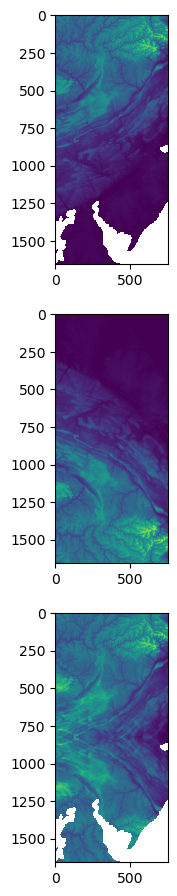

In [37]:
fig = plt.figure(figsize=(8.5,11))

ax = fig.add_subplot(311)
ax.imshow(src_dst_match)
ax.set_aspect('equal')
forceAspect(ax,aspect=dst_griddom.rio.shape[1]/dst_griddom.rio.shape[0])

ax = fig.add_subplot(312)
ax.imshow(dst_griddom[0])
ax.set_aspect('equal')
forceAspect(ax,aspect=dst_griddom.rio.shape[1]/dst_griddom.rio.shape[0])

ax = fig.add_subplot(313)
ax.imshow(xds_sum)
ax.set_aspect('equal')
forceAspect(ax,aspect=dst_griddom.rio.shape[1]/dst_griddom.rio.shape[0])

In [38]:
os.path.join(Paths.project_root, ngwm_tag, modelname)

'/glade/work/felfelan/MODFLOW/ngwm/ngwm1.0/modflow_subset'

### Create a directory and subset the data from the CONUS-extent netCDFs

In [45]:
idomain = np.ones((dst_griddom.shape[1], dst_griddom.shape[2]))
idomain = np.ma.masked_invalid(np.ma.masked_greater(src_dst_match, 0).filled(1)).filled(0)
idomain = np.ma.masked_invalid(np.ma.masked_greater_equal(src_dst_match, 0).filled(1)).filled(0)

idomain_file = os.path.join(sim_ws, '{}.{}'.format(modelname, 'idomain'))
np.savetxt(idomain_file, idomain, fmt='%5i')

In [46]:
def grid_subsetter(dirname, varnme, sim_ws=sim_ws, modelname=modelname):
    """Helper function. Writes a subset of the CONUS data to ASCII."""

    nc_fin = os.path.join(dirname, 'ngwm1.0_250_{}.nc'.format(varnme))
    da = xr.open_dataarray(nc_fin)#.sel(x=X_sel, y=Y_sel)
    
    print(" ")
    print('Var Name: ', varnme)
    
    print("Original dat, MAX: {0}, MIN: {1}".format(da.data.max(), da.data.min()))

    src_dst_match = da.rio.reproject_match(dst_griddom)
    src_dst_match = src_dst_match.assign_coords({
    "x": dst_griddom.x,
    "y": dst_griddom.y,
    })

    if varnme in ["npf_hk", "pak_rch", "pak_drn_conductance", "pak_ghb_conductance"]:
        unitchange = 1./24.   # per day to per hour

    else:
        unitchange = 1.0

    print("unitchange: {0}".format(unitchange))
    fout_ext = da.name
    for ipakvar in ['conductance', 'stage']:
        if varnme.endswith(ipakvar):
            fout_ext += '_{}'.format(ipakvar)

    print("fout_ext: {0}".format(fout_ext))

    fout = os.path.join(sim_ws, '{}.{}'.format(modelname, fout_ext))

    print("Subsetted dat, MAX: {0}, MIN: {1}".format(src_dst_match.data.max(), src_dst_match.data.min()))
    print("Count number of Cells: {0}".format(src_dst_match.data.size))
    print("Count number of Non-Zero Non-NAN: {0}".format(np.count_nonzero(~np.isnan(src_dst_match.data))))
    # print("Count number of Non-NAN: {0}".format(~np.isnan(src_dst_match.data).size))
    print("Count number of Non-Zero NAN: {0}".format(np.count_nonzero(np.isnan(src_dst_match.data))))

    # if varnme != "cbc_drn":
    #     np.savetxt(fout, src_dst_match.data*unitchange, fmt='%15.8f')

    print('done writing ', fout)
    print(" ")

    return fout, src_dst_match.data, unitchange

 
Var Name:  frame_top
Original dat, MAX: nan, MIN: nan
unitchange: 1.0
fout_ext: top
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 1134678
Count number of Non-Zero NAN: 106415
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.top
 


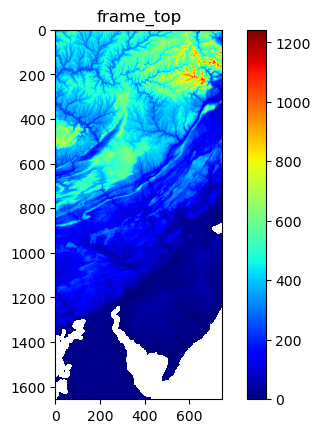

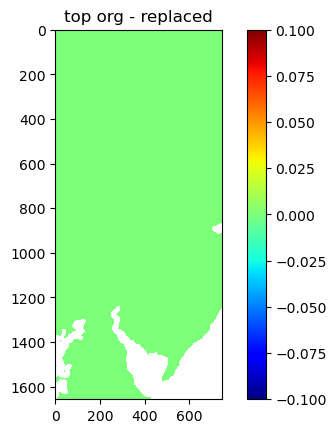

 
Var Name:  frame_bottoms
Original dat, MAX: nan, MIN: nan
unitchange: 1.0
fout_ext: bottoms
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 1134678
Count number of Non-Zero NAN: 106415
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.bottoms
 


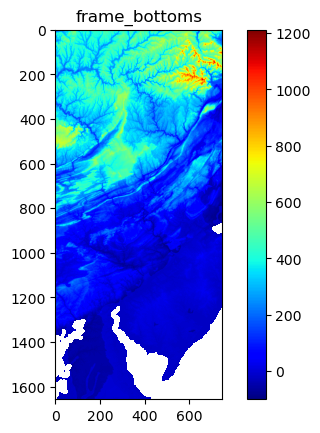

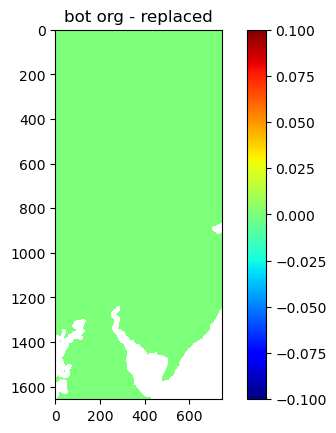

 
Var Name:  npf_hk
Original dat, MAX: nan, MIN: nan
unitchange: 0.041666666666666664
fout_ext: hk
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 1134678
Count number of Non-Zero NAN: 106415
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.hk
 


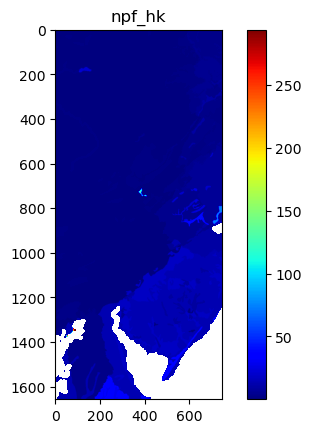

 
Var Name:  pak_rch
Original dat, MAX: nan, MIN: nan
unitchange: 0.041666666666666664
fout_ext: rch
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 1134678
Count number of Non-Zero NAN: 106415
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.rch
 


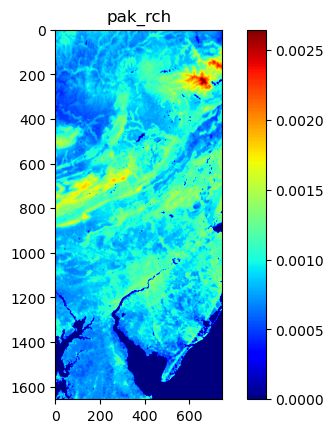

 
Var Name:  pak_drn_stage
Original dat, MAX: nan, MIN: nan
unitchange: 1.0
fout_ext: drn_stage
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 1103685
Count number of Non-Zero NAN: 137408
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.drn_stage
 


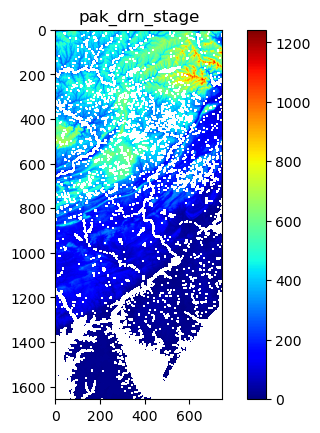

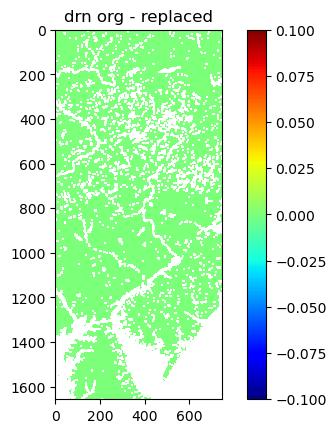

 
Var Name:  pak_drn_conductance
Original dat, MAX: nan, MIN: nan
unitchange: 0.041666666666666664
fout_ext: drn_conductance
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 1103685
Count number of Non-Zero NAN: 137408
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.drn_conductance
 


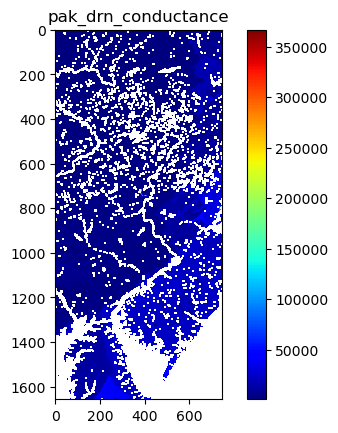

 
Var Name:  pak_ghb_stage
Original dat, MAX: nan, MIN: nan
unitchange: 1.0
fout_ext: ghb_stage
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 30968
Count number of Non-Zero NAN: 1210125
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.ghb_stage
 


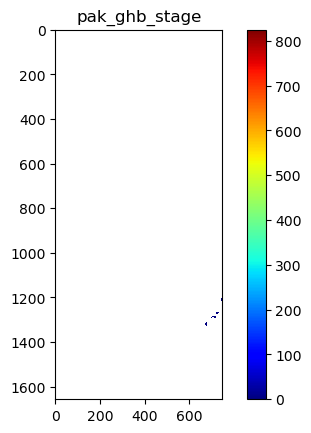

 
Var Name:  pak_ghb_conductance
Original dat, MAX: nan, MIN: nan
unitchange: 0.041666666666666664
fout_ext: ghb_conductance
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 30968
Count number of Non-Zero NAN: 1210125
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.ghb_conductance
 


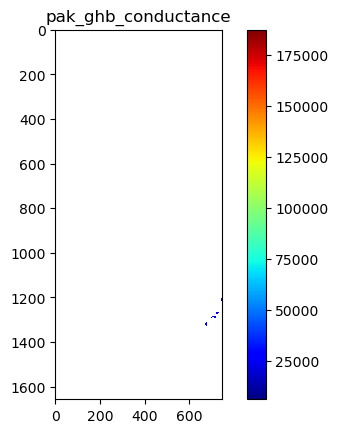

 
Var Name:  pak_chd_stage
Original dat, MAX: nan, MIN: nan
unitchange: 1.0
fout_ext: chd_stage
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 2661
Count number of Non-Zero NAN: 1238432
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.chd_stage
 


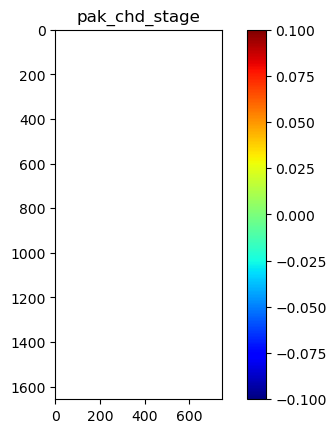

 
Var Name:  hds_hds
Original dat, MAX: nan, MIN: nan
unitchange: 1.0
fout_ext: hds
Subsetted dat, MAX: nan, MIN: nan
Count number of Cells: 1241093
Count number of Non-Zero Non-NAN: 1134678
Count number of Non-Zero NAN: 106415
done writing  /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/modflow_cutout/drb_250m_v01/modflow_subset/modflow_subset.hds
 


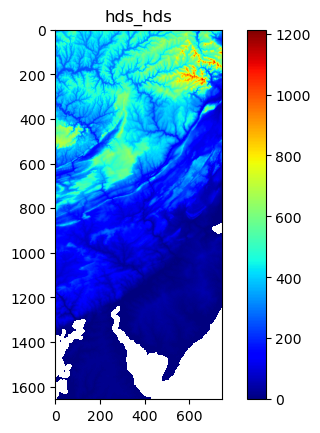

In [47]:
# Write the data arrays for the model framework
for ivarnme in ['frame_top', 'frame_bottoms']:
    dirname = Paths.framedata_dir
    fout, ds_dat, unitchange = grid_subsetter(dirname, varnme=ivarnme)
    
    if ivarnme == 'frame_top':
        top_dat = ds_dat
    if ivarnme == 'frame_bottoms':
        bot_dat = ds_dat

    if replaceTop and ivarnme == "frame_top":
        m = np.ma.masked_invalid(ds_dat)
        m = np.ma.masked_equal(~m.mask, 0)
        ds_dat = (dst_griddom_flip.data[0]*m).filled(np.nan)

    if replaceTop and ivarnme == "frame_bottoms":

        thickn = top_dat - bot_dat
        m = np.ma.masked_invalid(ds_dat)
        m = np.ma.masked_equal(~m.mask, 0)
        ds_dat = ((dst_griddom_flip.data[0] - thickn)*m).filled(np.nan)    

    np.savetxt(fout, ds_dat*unitchange, fmt='%15.8f')
    
    plt.imshow(ds_dat.data, cmap=plt.cm.jet); plt.colorbar()
    plt.title(ivarnme)
    plt.show()

    if ivarnme == 'frame_top':
        plt.imshow(top_dat - ds_dat.data, cmap=plt.cm.jet); plt.colorbar()
        plt.title("top org - replaced")
        plt.show()

    if ivarnme == 'frame_bottoms':
        plt.imshow(bot_dat - ds_dat.data, cmap=plt.cm.jet); plt.colorbar()
        plt.title("bot org - replaced")
        plt.show()

# top_dat = grid_subsetter(Paths.framedata_dir, varnme='frame_top')

# Write the data array for the flow packages and boundary conditions
for ivarnme in ['npf_hk',
                'pak_rch',
                'pak_drn_stage', 'pak_drn_conductance',
                'pak_ghb_stage', 'pak_ghb_conductance',
                'pak_chd_stage']:
    #####################################   =========================> NEED TO UPDATE GHB AND CHD STAGE IF REPLACE TOP!!!!!!!
    dirname = Paths.pakdata_dir
    fout, ds_dat, unitchange = grid_subsetter(dirname, varnme=ivarnme)


    if ivarnme == 'pak_rch':
        ds_dat = np.ma.masked_invalid(ds_dat).filled(0)

    if ivarnme == 'pak_drn_stage':
        drn_dat = ds_dat

    if replaceTop and ivarnme == "pak_drn_stage":
        m = np.ma.masked_invalid(ds_dat)
        m = np.ma.masked_equal(~m.mask, 0)
        ds_dat = (dst_griddom_flip.data[0]*m).filled(np.nan)

    np.savetxt(fout, ds_dat*unitchange, fmt='%15.8f')    
    
    plt.imshow(ds_dat.data, cmap=plt.cm.jet); plt.colorbar()
    plt.title(ivarnme)
    plt.show()

    if ivarnme == 'pak_drn_stage':
        plt.imshow(drn_dat - ds_dat.data, cmap=plt.cm.jet); plt.colorbar()
        plt.title("drn org - replaced")
        plt.show()

# drn_dat = grid_subsetter(Paths.pakdata_dir, varnme='pak_drn_stage')

# Write the data array for the ngwm1.0 output. We will use these for starting heads
for ivarnme in ['hds_hds']:

    dirname = Paths.modeldata_dir
    fout, ds_dat, unitchange = grid_subsetter(dirname, varnme=ivarnme)
    np.savetxt(fout, ds_dat*unitchange, fmt='%15.8f')

    plt.imshow(ds_dat.data, cmap=plt.cm.jet); plt.colorbar()
    plt.title(ivarnme)
    plt.show()

# Rename the ascii of ngwm1.0 subsetted heads to disambiguate from the heads binary that will be written
# by the re-simulation
hds_ngwm1_0 = os.path.join(sim_ws, '{}.{}'.format(modelname, 'hds'))
hds_rename  = hds_ngwm1_0.replace('.hds', '.startingheads')

shutil.copyfile(hds_ngwm1_0, hds_rename)
os.remove(hds_ngwm1_0)

The current contents of the MODFLOW workspace

In [49]:
os.listdir(sim_ws)  # These are all ascii arrays == ngwm1.0 data subsetted to (sample) MODFLOW grid

['modflow_subset.chd_stage',
 'modflow_subset.ghb_conductance',
 'modflow_subset.idomain',
 'modflow_subset.drn_conductance',
 'modflow_subset.startingheads',
 'modflow_subset.top',
 'modflow_subset.hk',
 'modflow_subset.drn_stage',
 'modflow_subset.bottoms',
 'modflow_subset.rch',
 'modflow_subset.ghb_stage']